In [ ]:
!pip install -q transformers datasets accelerate scikit-learn grapheme


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install torch torchvision torchaudio


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving trainV2.csv to trainV2.csv


In [ ]:
import pandas as pd
df = pd.read_csv("trainV2.csv")
df.head()

,Text,Class
0,நான் கூட உன்னை வெகுளியான பொண்ணு&#39;னு நெனச்சி...,Non-Abusive
1,உன் போட்டோவை டாய்லெட்டுக்கு மாற்றினார்கள் அசிங...,Abusive
2,கண்டா வரச்சொல்லுங்க கார்த்திய திவ்யாவோட சேர்த்...,Non-Abusive
3,ஒன்னோட சைசுக்கு நீயே ஒரு நாளக்கி 5கிலோ ஆய் போவ...,Abusive
4,ரெண்டும் மிக பெரிய வெடிகுண்டு இவங்கள எதுக்கு ஷ...,Non-Abusive


In [ ]:
import re, html, unicodedata
import grapheme

def grapheme_preprocess(text):
    text = str(text)

    # decode html
    text = html.unescape(text)

    # normalize unicode (VERY IMPORTANT)
    text = unicodedata.normalize("NFC", text)

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # extract grapheme clusters
    clusters = list(grapheme.graphemes(text))

    # rejoin normalized graphemes
    text = "".join(clusters)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
df["grapheme_text"] = df["Text"].apply(grapheme_preprocess)
df["clean_text"] = df["Text"]  # baseline version


In [ ]:
TEXT_COL = "grapheme_text"
#TEXT_COL = "clean_text" for baseline version

In [ ]:
print(df.columns)


Index(['Text', 'Class', 'grapheme_text', 'clean_text'], dtype='object')


In [ ]:
df["label"] = df["Class"].map({
    "Non-Abusive":0,
    "Abusive":1
})


In [ ]:
# normalize label text
df["Class"] = df["Class"].astype(str).str.strip().str.lower()

print("Unique labels after cleaning:", df["Class"].unique())

# map to numeric
df["label"] = df["Class"].map({
    "abusive":1,
    "non-abusive":0,
    "non abusive":0
})

# check if any missing
print("NaN labels count:", df["label"].isna().sum())

Unique labels after cleaning: ['non-abusive' 'abusive']
NaN labels count: 0


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df[[TEXT_COL,"label"]],
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "l3cube-pune/tamil-bert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/450 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/951M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: l3cube-pune/tamil-bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trainin

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df.rename(columns={TEXT_COL:"text"})
)
val_dataset = Dataset.from_pandas(
    val_df.rename(columns={TEXT_COL:"text"})
)


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])
val_dataset.set_format("torch", columns=["input_ids","attention_mask","label"])


Map:   0%|          | 0/3286 [00:00<?, ? examples/s]

Map:   0%|          | 0/366 [00:00<?, ? examples/s]

In [ ]:
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.530921,0.786885,0.763636
2,No log,0.449886,0.830601,0.834225
3,0.487890,0.468104,0.819672,0.827225
4,0.487890,0.495574,0.816940,0.825065
5,0.268839,0.489836,0.819672,0.817680


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1030, training_loss=0.3738072904568274, metrics={'train_runtime': 622.5332, 'train_samples_per_second': 26.392, 'train_steps_per_second': 1.655, 'total_flos': 1080728659891200.0, 'train_loss': 0.3738072904568274, 'epoch': 5.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.4453500509262085,
 'eval_accuracy': 0.8333333333333334,
 'eval_f1': 0.8364611260053619,
 'eval_runtime': 3.0518,
 'eval_samples_per_second': 119.93,
 'eval_steps_per_second': 7.537,
 'epoch': 5.0}

In [ ]:
trainer.save_model("best_model_10_grapheme")
tokenizer.save_pretrained("best_model_10_grapheme")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('best_model_10_grapheme/tokenizer_config.json',
 'best_model_10_grapheme/tokenizer.json')

In [ ]:
import shutil
shutil.make_archive("tamilbert_grapheme_best_model_10", 'zip', "best_model_10_grapheme")


'/content/tamilbert_grapheme_best_model_10.zip'

In [ ]:
from google.colab import files
files.download("tamilbert_grapheme_best_model_10.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions on the validation set
predictions = trainer.predict(val_dataset)

# Extract logits and labels
# predictions.predictions are the raw scores (logits)
# np.argmax converts these into class indices (0 or 1)
y_preds = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Extract probabilities for the ROC curve (usually the score for class 1)
# We use softmax to turn logits into 0.0 - 1.0 probabilities
import torch.nn.functional as F
import torch
probs = F.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()[:, 1]

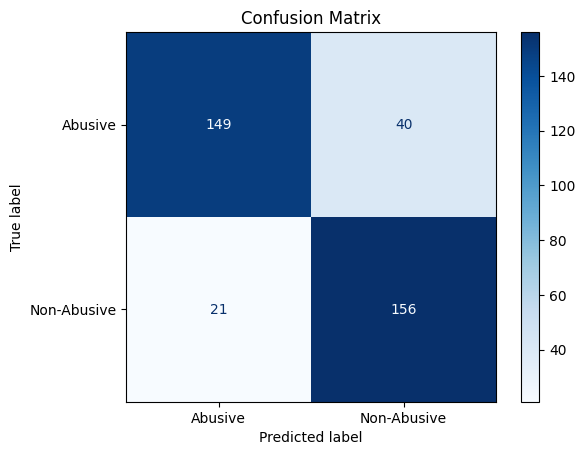

              precision    recall  f1-score   support

     Abusive       0.88      0.79      0.83       189
 Non-Abusive       0.80      0.88      0.84       177

    accuracy                           0.83       366
   macro avg       0.84      0.83      0.83       366
weighted avg       0.84      0.83      0.83       366



In [ ]:
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Abusive", "Non-Abusive"])

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Print text report (Precision, Recall, F1)
print(classification_report(y_true, y_preds, target_names=["Abusive", "Non-Abusive"]))

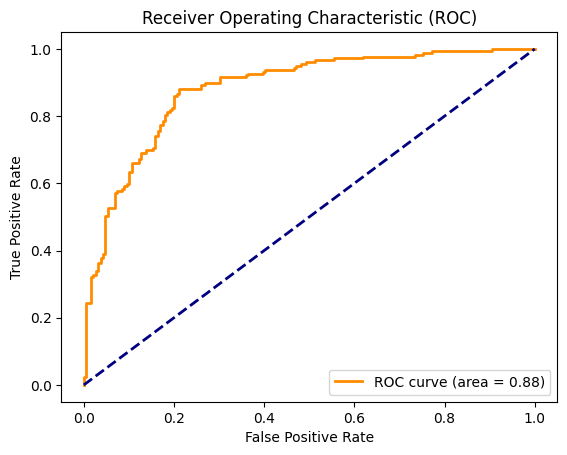

In [ ]:
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

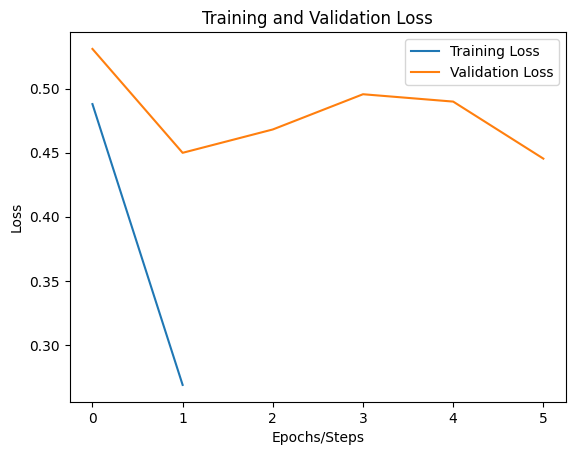

In [ ]:
history = trainer.state.log_history

# Extract loss values
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.plot(train_loss, label='Training Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.xlabel('Epochs/Steps')
plt.ylabel('Loss')
plt.legend()
plt.title("Training and Validation Loss")
plt.show()